# Introducing graph structures for measles

While I am some graph structures representing Kreis-Kreis connectivity in Germany, for measles we'll need more. We'll need a way of linking each municipality to international flights data. I have a couple of thoughts for this:

**Option 1: Three-layered graph system**
The most beautiful system would probably be a graph that is a collection of L1, L2 and L3, as follows:

- *L1*: country -> airport
- *L2*: airport -> Kreis
- *L3*: Kreis   -> Kreis (what I currently have for influenza)

**Option 2: Two-layered graph system**
Option 1 seems difficult though. So I think I'll start with *L12* and *L3*, in which *L12* represents a network of the airports, connected to Kreisen, in which the airports are associated with features representing the risk factors.

This option has a couple of different suboptions. On the one hand I could introduce 

## Epidemiology data

**World Harmonization**

I got 195 countries, accross 7 continents and 22 regions.

**Global measles cases**

I got 191 countries

**Global population size**

I got 194 countries

Luckily, all of the countries in each dataset are also in the world harmonization, so I'll be using that as reference. I'll be using the entire 195 countries.

These I merge into one pd.Dataframe with 

| id | timestamp | incidence |



In [2]:
import geopandas as gpd
import pandas as pd 
import matplotlib.pyplot as plt 
import os 
import seaborn as sns

from src.utils import get_data_env

In [68]:
world_harm                  = pd.read_csv(os.path.join(get_data_env(), 'processed/international/geospatial/harmonization/world_harmonization.tsv'), sep = "\t")
global_measles_cases        = pd.read_csv(os.path.join(get_data_env(), 'processed/international/epidemiology/casedata/who_mv_monthly.csv'))
global_measles_vaccination1 = pd.read_csv(os.path.join(get_data_env(), 'processed/international/epidemiology/vaxdata/who_mcv1.csv'))
global_measles_vaccination2 = pd.read_csv(os.path.join(get_data_env(), 'processed/international/epidemiology/vaxdata/who_mcv2.csv'))
global_population_size      = pd.read_csv(os.path.join(get_data_env(), 'processed/international/sociodemography/population_size.csv'))

In [115]:
from typing import Dict, Tuple
import pandas as pd

################
# Tokenization #
################
def make_tokenization_map(df: pd.DataFrame, col: str) -> Tuple[Dict[str,int], Dict[int,str]]:
    """
    from input dataframe, which is the world harmonization dataframe,
    this function returns two dictionaries of the tokenization 
    the first is the string of the country name - token and the s
    econd is token - country name
    """
    unique_countries    = sorted(list(df[col].unique()))
    colvalue_token       = {}
    token_colvalue       = {}

    for idx, cc in enumerate(unique_countries):
        colvalue_token[cc] = idx 
        token_colvalue[idx]= cc 

    return colvalue_token, token_colvalue

def tokenize_df(df: pd.DataFrame, map: Dict[str, int], col: str) -> pd.DataFrame:
    """create new column 'id' from 'country' column, using mapping"""

    dfc         = df.copy()
    dfc['id']= dfc[col].map(map)

    return dfc

###################
# epi preparation #
###################
def filter_dates(df: pd.DataFrame, min_date: str = '2012-01-01', max_date: str = '2020-01-01') -> pd.DataFrame:
    """filter on min and max date"""
    dfc = df.copy()

    if 'timestamp' not in df.columns and 'year' in df.columns:
        dfc['timestamp'] = pd.to_datetime(dfc['year'].astype(str) + '-01-01')


    dfc = dfc[dfc['timestamp']< max_date]
    dfc = dfc[dfc['timestamp']>=min_date]
    
    if 'year' in df.columns:
        dfc = dfc.drop(columns = 'timestamp')

    return dfc.reset_index(drop = True)


def get_epidemiological_df(population_df: pd.DataFrame, cases_df: pd.DataFrame):
    epi_df              = pd.merge(population_df, cases_df, on = ['country','year'])
    epi_df['incidence'] = epi_df['cases'] / epi_df['population_size'] * 100_000
    epi_df['timestamp'] = pd.to_datetime(epi_df['timestamp'])
    return epi_df
    



In [116]:
population_df   = filter_dates(global_population_size)
epi_df          = get_epidemiological_df(population_df,global_measles_cases)

country_token, token_country = make_tokenization_map(world_harm, 'country')

world_harm              = tokenize_df(world_harm, country_token, 'country')
epi_df                  = tokenize_df(epi_df, country_token, 'country')

In [103]:
def plot_country_incidence(df: pd.DataFrame, country: str = 'Germany'):

    fig, ax = plt.subplots(1,1, figsize = (8,4))
    sns.lineplot(df[df['country'] == country], x ='timestamp', y = 'incidence', marker='o', ax= ax)
    ax.set_title(f'measles incidence {country} per 100 000')
    ax.grid()

    fig.show()

/local/job_23203755/ipykernel_3649662/1835323080.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


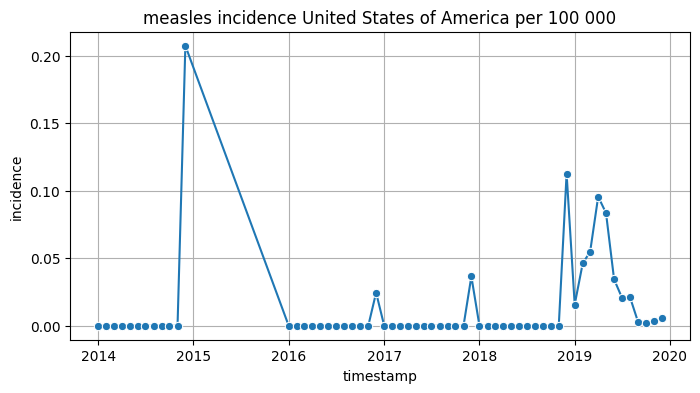

In [109]:
plot_country_incidence(epi_df, 'United States of America')

## Airport data

I now ultimately want:

| airport | timestamp | ori_country | passengers | incidence |

In [ ]:
flights_data    = pd.read_csv(os.path.join(get_data_env(), 'processed/international/mobility/travel/country_german_airp/selection2.csv'))
flights_data    = filter_dates(flights_data)

tokenize_df(flights_data)

In [128]:
airport_token, token_airport = make_tokenization_map(flights_data, 'dest_airport_code')
flights_data                 = tokenize_df(flights_data, airport_token, 'dest_airport_code')
flights_data['timestamp']    = pd.to_datetime(flights_data['timestamp'])

In [131]:
prepped_epidata = epi_df[['country','timestamp','incidence']].rename(columns = {'country':'ori_country'})
prepped_flights_data = flights_data[['dest_airport_code','timestamp','ori_country','passengers']].rename(columns = {'dest_airport_code':'airport'})

MAIN_data = prepped_flights_data.merge(prepped_epidata, on = ['timestamp','ori_country'])

In [133]:
df = MAIN_data.copy()

TOP 20 ANOMALOUS HIGH-RISK MONTHS (Statistical Outliers)
     airport  timestamp  expected_infected      mean   z_score
1792     KSF 2018-05-01           0.081225  0.002957  7.101835
1306     GWT 2013-05-01           0.064259  0.005468  6.161067
2979     XFW 2018-03-01           0.042290  0.003233  5.872765
74       AGB 2018-03-01           0.008239  0.000777  5.658468
898      FDH 2019-05-01           0.668429  0.046274  5.520265
993      FKB 2019-04-01           0.835750  0.094627  5.317704
994      FKB 2019-05-01           0.806144  0.094627  5.105278
897      FDH 2019-04-01           0.618204  0.046274  5.074631
282      BWE 2015-03-01           0.002990  0.000258  4.977464
91       BER 2012-06-01           0.210768  0.016311  4.917966
269      BRE 2019-04-01           1.065321  0.148450  4.914995
2980     XFW 2018-04-01           0.035245  0.003233  4.813462
270      BRE 2019-05-01           1.028833  0.148450  4.719400
2501     RLG 2018-05-01           0.042850  0.006092  4.58294

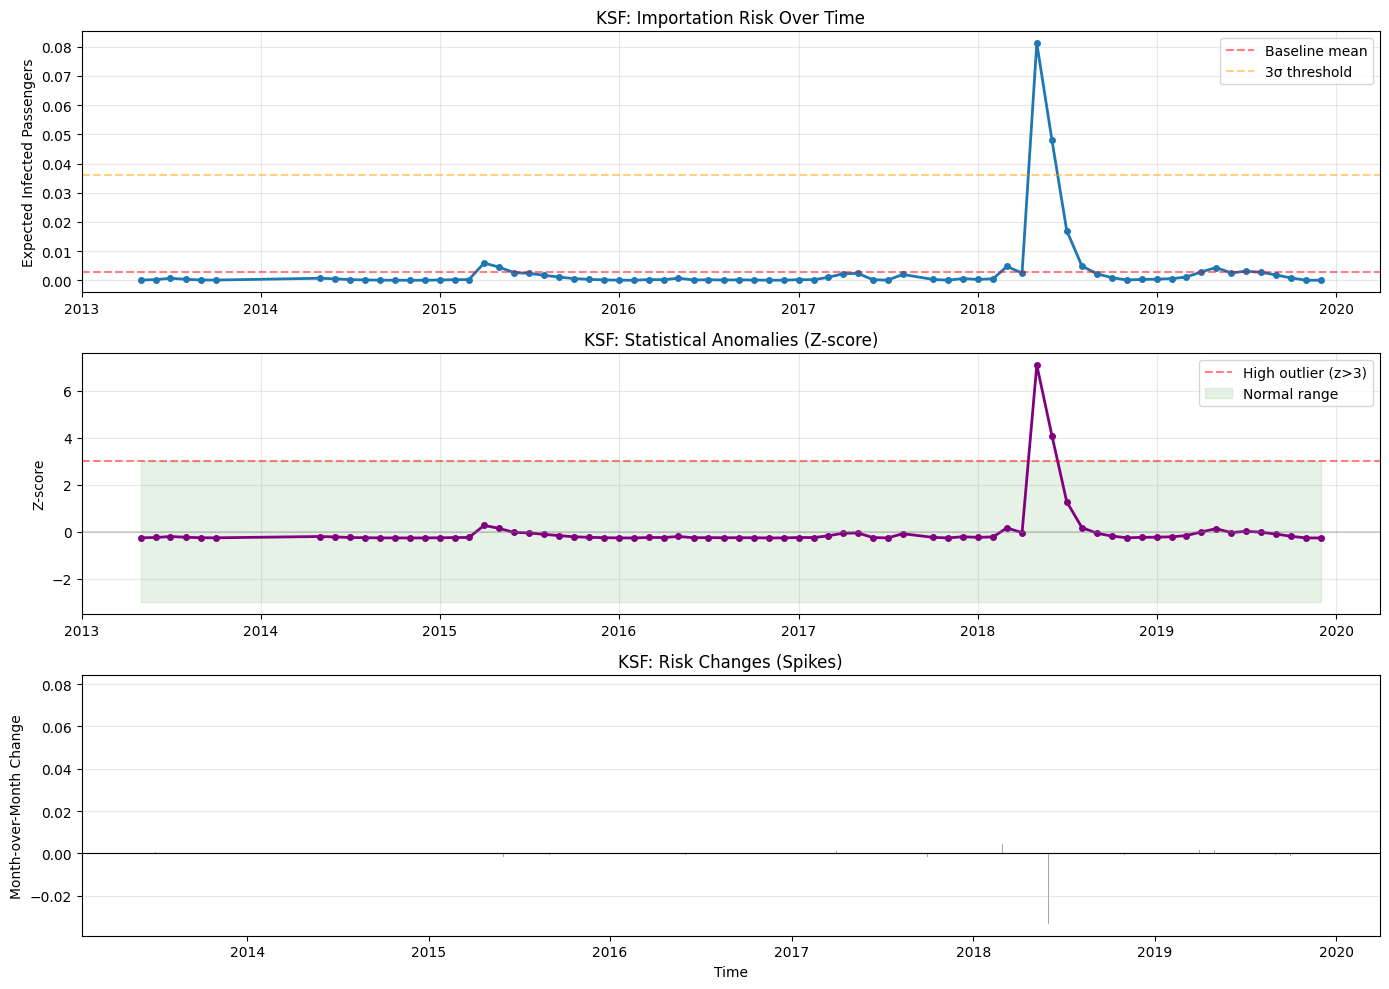


ANOMALOUS MONTHS FOR KSF

May 2018:
  Expected infected: 0.081 passengers
  Z-score: 7.10 (baseline: 0.003 ± 0.011)
  Change from prev month: 0.079
  Top contributing countries:
    - Greece: 0.078 (3344 pax, 2.3 per 100k)
    - Spain: 0.003 (2886 pax, 0.1 per 100k)
    - Italy: 0.001 (132 pax, 0.8 per 100k)
    - Bulgaria: 0.000 (536 pax, 0.0 per 100k)
    - Israel: 0.000 (8 pax, 0.4 per 100k)

June 2018:
  Expected infected: 0.048 passengers
  Z-score: 4.08 (baseline: 0.003 ± 0.011)
  Change from prev month: -0.033
  Top contributing countries:
    - Greece: 0.045 (4355 pax, 1.0 per 100k)
    - Spain: 0.002 (4273 pax, 0.1 per 100k)
    - Bulgaria: 0.000 (1264 pax, 0.0 per 100k)
    - Israel: 0.000 (8 pax, 0.8 per 100k)
    - Morocco: 0.000 (1 pax, 0.0 per 100k)

RECOMMENDED CASES TO CROSS-CHECK WITH ACTUAL MEASLES DATA

Top candidates (specific month-airport pairs):

1793. KSF - May 2018
   Expected infected: 0.081
   Z-score: 7.10
   → Check measles cases in municipalities near thi

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# First, compute properly scaled risk
df['expected_infected'] = (df['passengers'] * df['incidence']) / 100_000

# Aggregate to airport-month level
airport_monthly = df.groupby(['airport', 'timestamp']).agg({
    'expected_infected': 'sum',
    'passengers': 'sum',
    'risk': 'sum'
}).reset_index()

airport_monthly['year'] = airport_monthly['timestamp'].dt.year
airport_monthly['month'] = airport_monthly['timestamp'].dt.month

# ==============================================================================
# Method 1: Find Statistical Outliers (Z-score approach)
# ==============================================================================

# Calculate baseline statistics for each airport
airport_stats = airport_monthly.groupby('airport')['expected_infected'].agg(['mean', 'std'])

# Merge back and compute z-scores
airport_monthly = airport_monthly.merge(
    airport_stats, 
    left_on='airport', 
    right_index=True,
    suffixes=('', '_baseline')
)

airport_monthly['z_score'] = (
    (airport_monthly['expected_infected'] - airport_monthly['mean']) / 
    airport_monthly['std']
)

# Find extreme outliers (z-score > 3 means very unusual)
outliers = airport_monthly[airport_monthly['z_score'] > 3].copy()
outliers = outliers.sort_values('z_score', ascending=False)

print("="*80)
print("TOP 20 ANOMALOUS HIGH-RISK MONTHS (Statistical Outliers)")
print("="*80)
print(outliers[['airport', 'timestamp', 'expected_infected', 'mean', 'z_score']].head(20))

# ==============================================================================
# Method 2: Find Sudden Spikes (Change from previous month)
# ==============================================================================

# Sort by airport and time
airport_monthly = airport_monthly.sort_values(['airport', 'timestamp'])

# Calculate month-over-month change
airport_monthly['risk_prev_month'] = airport_monthly.groupby('airport')['expected_infected'].shift(1)
airport_monthly['risk_change'] = airport_monthly['expected_infected'] - airport_monthly['risk_prev_month']
airport_monthly['risk_pct_change'] = (
    airport_monthly['risk_change'] / 
    (airport_monthly['risk_prev_month'] + 0.001)  # avoid division by zero
) * 100

# Find sudden spikes
spikes = airport_monthly[
    (airport_monthly['risk_change'] > 0.5) &  # absolute increase > 0.5 expected infected
    (airport_monthly['expected_infected'] > 1.0)  # and current risk is substantial
].copy()
spikes = spikes.sort_values('risk_change', ascending=False)

print("\n" + "="*80)
print("TOP 20 SUDDEN SPIKES (Large month-over-month increases)")
print("="*80)
print(spikes[['airport', 'timestamp', 'risk_prev_month', 'expected_infected', 'risk_change']].head(20))

# ==============================================================================
# Method 3: Find Year-Airport combinations with sustained high risk
# ==============================================================================

# Aggregate to airport-year level
airport_yearly = airport_monthly.groupby(['airport', 'year']).agg({
    'expected_infected': ['sum', 'mean', 'max'],
    'passengers': 'sum'
}).reset_index()

airport_yearly.columns = ['airport', 'year', 'total_risk', 'mean_risk', 'max_risk', 'total_passengers']

# Find years with unusually high risk
airport_yearly = airport_yearly.sort_values('total_risk', ascending=False)

print("\n" + "="*80)
print("TOP 20 AIRPORT-YEAR COMBINATIONS (Sustained high risk)")
print("="*80)
print(airport_yearly[['airport', 'year', 'total_risk', 'mean_risk', 'max_risk']].head(20))

# ==============================================================================
# Method 4: Interactive - Pick specific airport and visualize
# ==============================================================================

def analyze_airport_over_time(airport_code, df_monthly):
    """
    Detailed analysis of one airport's risk over time
    """
    airport_data = df_monthly[df_monthly['airport'] == airport_code].copy()
    airport_data = airport_data.sort_values('timestamp')
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Plot 1: Risk over time
    axes[0].plot(airport_data['timestamp'], airport_data['expected_infected'], 
                 marker='o', linewidth=2, markersize=4)
    axes[0].axhline(airport_data['mean'].iloc[0], 
                    color='red', linestyle='--', alpha=0.5, label='Baseline mean')
    axes[0].axhline(airport_data['mean'].iloc[0] + 3*airport_data['std'].iloc[0], 
                    color='orange', linestyle='--', alpha=0.5, label='3σ threshold')
    axes[0].set_ylabel('Expected Infected Passengers')
    axes[0].set_title(f'{airport_code}: Importation Risk Over Time')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Z-score over time (shows statistical anomalies)
    axes[1].plot(airport_data['timestamp'], airport_data['z_score'], 
                 marker='o', linewidth=2, markersize=4, color='purple')
    axes[1].axhline(3, color='red', linestyle='--', alpha=0.5, label='High outlier (z>3)')
    axes[1].axhline(0, color='gray', linestyle='-', alpha=0.3)
    axes[1].fill_between(airport_data['timestamp'], -3, 3, alpha=0.1, color='green', label='Normal range')
    axes[1].set_ylabel('Z-score')
    axes[1].set_title(f'{airport_code}: Statistical Anomalies (Z-score)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Month-over-month change
    axes[2].bar(airport_data['timestamp'], airport_data['risk_change'], 
                color=['red' if x > 0.5 else 'gray' for x in airport_data['risk_change']], 
                alpha=0.7)
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_xlabel('Time')
    axes[2].set_ylabel('Month-over-Month Change')
    axes[2].set_title(f'{airport_code}: Risk Changes (Spikes)')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed info on anomalous months
    anomalies = airport_data[airport_data['z_score'] > 3].sort_values('z_score', ascending=False)
    if len(anomalies) > 0:
        print(f"\n{'='*80}")
        print(f"ANOMALOUS MONTHS FOR {airport_code}")
        print(f"{'='*80}")
        for idx, row in anomalies.iterrows():
            print(f"\n{row['timestamp'].strftime('%B %Y')}:")
            print(f"  Expected infected: {row['expected_infected']:.3f} passengers")
            print(f"  Z-score: {row['z_score']:.2f} (baseline: {row['mean']:.3f} ± {row['std']:.3f})")
            print(f"  Change from prev month: {row['risk_change']:.3f}")
            
            # Show which countries contributed
            monthly_detail = df[
                (df['airport'] == airport_code) & 
                (df['timestamp'] == row['timestamp'])
            ].sort_values('expected_infected', ascending=False)
            
            print(f"  Top contributing countries:")
            for _, country_row in monthly_detail.head(5).iterrows():
                print(f"    - {country_row['ori_country']}: {country_row['expected_infected']:.3f} "
                      f"({country_row['passengers']:.0f} pax, {country_row['incidence']:.1f} per 100k)")
    else:
        print(f"\nNo statistical anomalies found for {airport_code}")
    
    return airport_data

# ==============================================================================
# Run analysis for top airports
# ==============================================================================

# Find the most interesting airport (highest single-month risk)
top_airport = outliers.iloc[0]['airport'] if len(outliers) > 0 else airport_monthly['expected_infected'].idxmax()

print(f"\n{'='*80}")
print(f"DETAILED ANALYSIS FOR TOP AIRPORT: {top_airport}")
print(f"{'='*80}")

airport_analysis = analyze_airport_over_time(top_airport, airport_monthly)

# ==============================================================================
# Summary: Best candidates for validation
# ==============================================================================

print("\n" + "="*80)
print("RECOMMENDED CASES TO CROSS-CHECK WITH ACTUAL MEASLES DATA")
print("="*80)

# Get top 5 anomalies with enough signal
validation_candidates = outliers.head(10).copy()

print("\nTop candidates (specific month-airport pairs):")
for i, row in validation_candidates.iterrows():
    print(f"\n{i+1}. {row['airport']} - {row['timestamp'].strftime('%B %Y')}")
    print(f"   Expected infected: {row['expected_infected']:.3f}")
    print(f"   Z-score: {row['z_score']:.2f}")
    print(f"   → Check measles cases in municipalities near this airport in {row['timestamp'].strftime('%B-%Y')} and following 2-3 weeks")

# Also suggest some year-level checks
print("\n" + "-"*80)
print("Year-level patterns to check:")
for i, row in airport_yearly.head(5).iterrows():
    print(f"\n{i+1}. {row['airport']} - {int(row['year'])}")
    print(f"   Total annual risk: {row['total_risk']:.2f}")
    print(f"   → Check if this year had elevated measles cases near this airport")

In [137]:
airport_shapes = gpd.read_file(os.path.join(get_data_env(), 'processed/international/geospatial/shapefiles/iata_airports.shp'))

shapefile_nuts3 = gpd.read_file(os.path.join(get_data_env(), 'processed/germany/geospatial/shapefiles/shape_nuts3.shp'))
shapefile_nuts2 = gpd.read_file(os.path.join(get_data_env(), 'processed/germany/geospatial/shapefiles/shape_nuts2.shp'))
shapefile_nuts1 = gpd.read_file(os.path.join(get_data_env(), 'processed/germany/geospatial/shapefiles/shape_nuts1.shp'))
shapefile_nuts0 = gpd.read_file(os.path.join(get_data_env(), 'processed/germany/geospatial/shapefiles/shape_nuts0.shp'))

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23203755/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


Text(0.5, 1.0, 'Airports Germany')

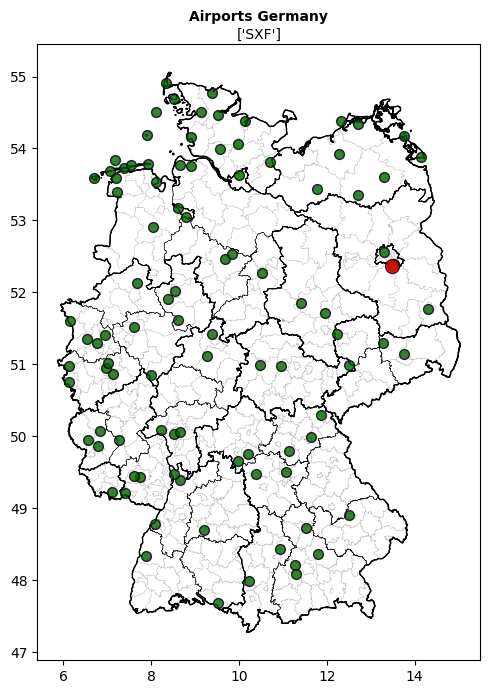

In [146]:
fig, ax = plt.subplots(1,1,figsize = (8,8))

airport_filter = ['SXF']

airports_germany = airport_shapes[airport_shapes['country'] == 'DE']
airports_sel     = airports_germany[airports_germany['code'].isin(airport_filter)]

shapefile_nuts3.plot(ax=ax, facecolor='white', edgecolor='darkgrey', linewidth=0.2)
shapefile_nuts2.plot(ax=ax, facecolor='none',  edgecolor='black',    linewidth=0.3)
shapefile_nuts1.plot(ax=ax, facecolor='none',  edgecolor='black',    linewidth=0.7)
shapefile_nuts0.plot(ax=ax, facecolor='none',  edgecolor='black',    linewidth=1)

ax.text(
        0.5, 1.005, f"{airport_filter}",
        transform=ax.transAxes,
        ha="center",
        va="bottom"
    )
airports_germany.plot(ax = ax, color='darkgreen', edgecolor = 'black', alpha = 0.8, label = 'Airport', markersize = 50)
airports_sel.plot(ax = ax, color='red', edgecolor = 'black', alpha = 0.8, label = 'Airport', markersize = 100)
ax.set_title(f'Airports Germany', fontsize = 10, fontweight = 'bold', pad = 17)